Artefact 5: Python Code – Dataset Validation and Preprocessing

In [ ]:
# ==========================================================
# EMPLOYEE ATTRITION MACHINE LEARNING PROJECT
# Dataset: IBM HR Analytics Employee Attrition Dataset
# ==========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ----------------------------------------------------------
# 1. LOAD DATASET
# ----------------------------------------------------------

df = pd.read_csv("IBM.csv")

print("Dataset shape:", df.shape)
print("\nFirst five rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

# ----------------------------------------------------------
# 2. DATA QUALITY CHECKS
# ----------------------------------------------------------

print("\nMissing values:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nAttrition distribution:")
print(df["Attrition"].value_counts())

print("\nAttrition percentage:")
print(df["Attrition"].value_counts(normalize=True) * 100)

# ----------------------------------------------------------
# 3. DEFINE TARGET AND PREDICTORS
# ----------------------------------------------------------

X = df.drop(columns=["Attrition"])

y = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

# ----------------------------------------------------------
# 4. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ----------------------------------------------------------

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("\nCategorical variables:")
print(categorical_features)

print("\nNumerical variables:")
print(numerical_features)

# ----------------------------------------------------------
# 5. STRATIFIED TRAIN-TEST SPLIT
# ----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

# ----------------------------------------------------------
# 6. PREPROCESSING
# ----------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\nProcessed training shape:",
      X_train_processed.shape)

print("Processed testing shape:",
      X_test_processed.shape)

Dataset shape: (1470, 13)

First five rows:
   Age Attrition              Department  DistanceFromHome  Education  \
0   41       Yes                   Sales                 1          2   
1   49        No  Research & Development                 8          1   
2   37       Yes  Research & Development                 2          2   
3   33        No  Research & Development                 3          4   
4   27        No  Research & Development                 2          1   

  EducationField  EnvironmentSatisfaction  JobSatisfaction MaritalStatus  \
0  Life Sciences                        2                4        Single   
1  Life Sciences                        3                2       Married   
2          Other                        4                3        Single   
3  Life Sciences                        4                3       Married   
4        Medical                        1                2       Married   

   MonthlyIncome  NumCompaniesWorked  WorkLifeBalance  Years

Artefact 6: Complete Model Development Code




In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.svm import SVC

from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ----------------------------------------------------------
# PREPROCESSOR
# ----------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

# ----------------------------------------------------------
# INDIVIDUAL MODELS
# ----------------------------------------------------------

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ),

    "Support Vector Machine":
        SVC(
            probability=True,
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        )
}

Artefact 7: Voting and Stacking Ensemble Code

In [3]:
# ----------------------------------------------------------
# BASE ESTIMATORS FOR ENSEMBLES
# ----------------------------------------------------------

ensemble_estimators = [

    (
        "lr",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    ),

    (
        "rf",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        )
    ),

    (
        "xgb",
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        )
    )
]

# ----------------------------------------------------------
# SOFT VOTING
# ----------------------------------------------------------

voting_model = VotingClassifier(
    estimators=ensemble_estimators,
    voting="soft"
)

# ----------------------------------------------------------
# STACKING
# ----------------------------------------------------------

stacking_model = StackingClassifier(
    estimators=ensemble_estimators,

    final_estimator=
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    stack_method="predict_proba",
    cv=5
)

models["Voting Ensemble"] = voting_model
models["Stacking Ensemble"] = stacking_model

Artefact 8: Training, SMOTE and Evaluation Code

In [4]:
results = []
trained_models = {}

for model_name, model in models.items():

    pipeline = Pipeline(
        steps=[
            (
                "preprocessing",
                preprocessor
            ),

            (
                "smote",
                SMOTE(
                    random_state=42
                )
            ),

            (
                "classifier",
                model
            )
        ]
    )

    # Train model
    pipeline.fit(
        X_train,
        y_train
    )

    # Predictions
    y_pred = pipeline.predict(
        X_test
    )

    y_probability = pipeline.predict_proba(
        X_test
    )[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_probability
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    trained_models[
        model_name
    ] = pipeline

# ----------------------------------------------------------
# RESULTS TABLE
# ----------------------------------------------------------

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

print(results_df.round(4))

                    Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0     Logistic Regression    0.6633     0.2500  0.5532    0.3444   0.6751
5         Voting Ensemble    0.8299     0.4400  0.2340    0.3056   0.6753
4                 XGBoost    0.8435     0.5263  0.2128    0.3030   0.6495
3  Support Vector Machine    0.7245     0.2344  0.3191    0.2703   0.5999
2           Random Forest    0.8333     0.4444  0.1702    0.2462   0.6669
6       Stacking Ensemble    0.8265     0.4000  0.1702    0.2388   0.6557
1           Decision Tree    0.7415     0.1778  0.1702    0.1739   0.4798


Artefact 9: Confusion Matrix Code

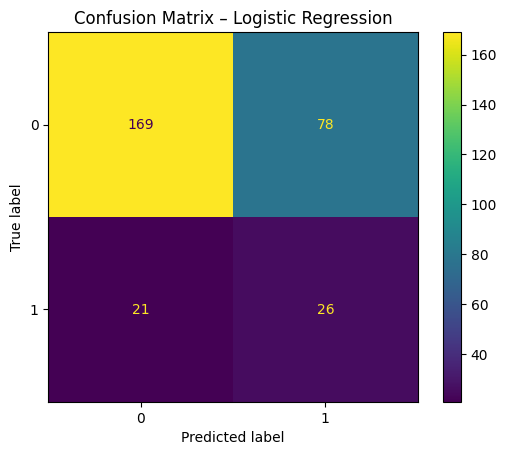

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

y_pred_best = best_model.predict(
    X_test
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best
)

plt.title(
    f"Confusion Matrix – {best_model_name}"
)

plt.show()

Artefact 10: ROC-AUC Code

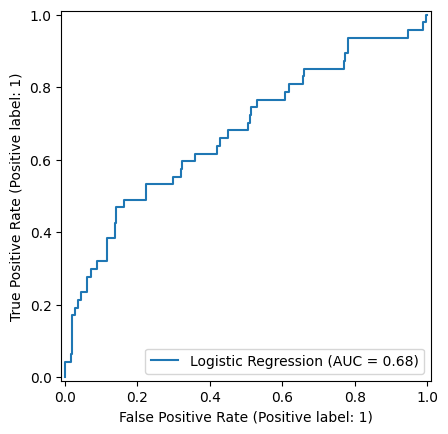

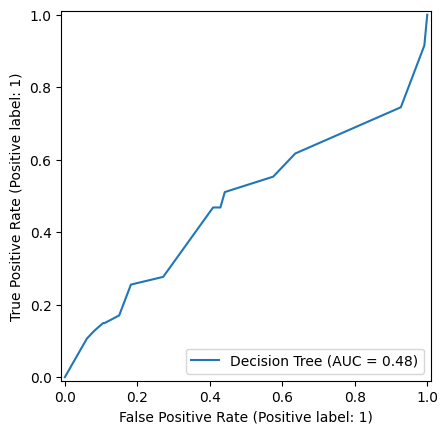

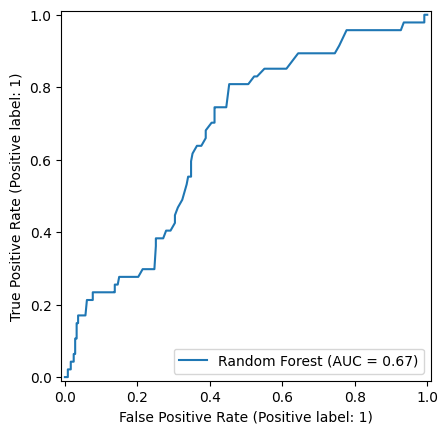

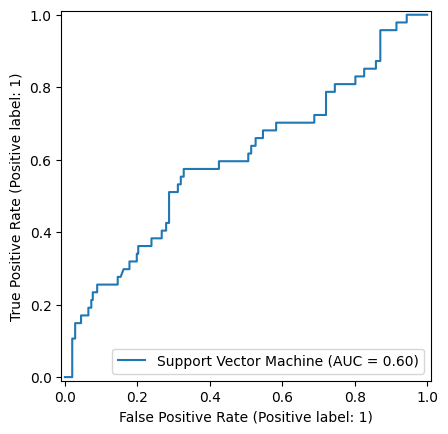

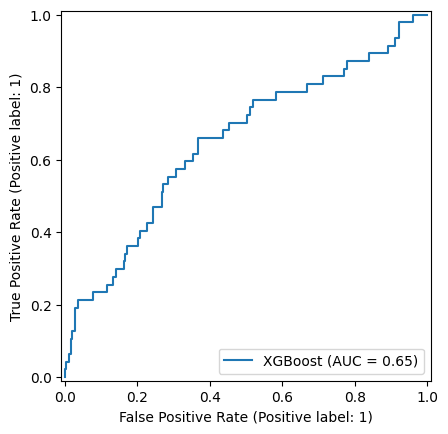

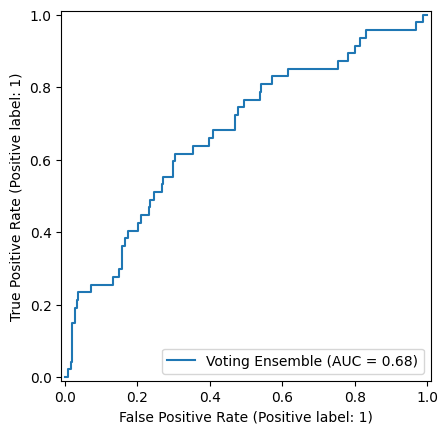

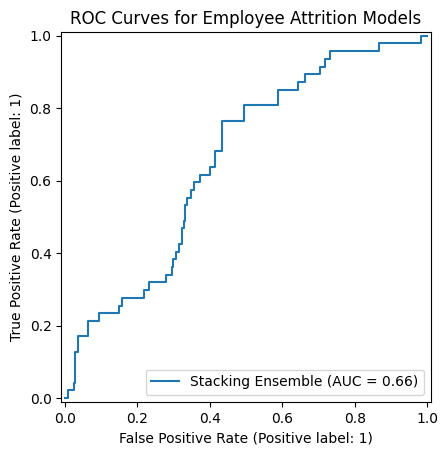

In [6]:
from sklearn.metrics import RocCurveDisplay

for model_name, model in trained_models.items():

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=model_name
    )

plt.title(
    "ROC Curves for Employee Attrition Models"
)

plt.show()

Artefact 11: Automated System Test Cases

In [7]:
# ==========================================================
# AUTOMATED TESTS
# ==========================================================

# Test 1: dataset loaded
assert df.shape[0] == 1470, \
    "Unexpected number of employee records"

# Test 2: expected target exists
assert "Attrition" in df.columns, \
    "Attrition target column missing"

# Test 3: no missing values
assert df.isnull().sum().sum() == 0, \
    "Missing values found"

# Test 4: no duplicate records
assert df.duplicated().sum() == 0, \
    "Duplicate rows found"

# Test 5: correct target encoding
assert set(y.unique()) == {0, 1}, \
    "Target encoding failed"

# Test 6: training and test data are separated
assert len(
    set(X_train.index)
    .intersection(
        set(X_test.index)
    )
) == 0, "Data leakage detected"

# Test 7: correct split size
assert len(X_train) == 1176
assert len(X_test) == 294

# Test 8: model produces one prediction per test record
test_model = trained_models[
    list(trained_models.keys())[0]
]

test_predictions = test_model.predict(
    X_test
)

assert len(test_predictions) == len(X_test), \
    "Prediction size mismatch"

# Test 9: predicted classes are valid
assert set(
    np.unique(test_predictions)
).issubset({0, 1}), \
    "Invalid predicted class"

# Test 10: probability is between 0 and 1
test_probability = test_model.predict_proba(
    X_test
)[:, 1]

assert np.all(
    (test_probability >= 0)
    &
    (test_probability <= 1)
), "Invalid probability values"

print(
    "All automated system tests passed successfully."
)

All automated system tests passed successfully.
